In [2]:
#Imports
import numpy as np
np.int = int

import configparser
configparser.SafeConfigParser = configparser.ConfigParser

import pylidc as pl
from pylidc.utils import consensus

import matplotlib.pyplot as plt

In [3]:
#Load a patient
scan = pl.query(pl.Scan).first()

print("Paciente:", scan.patient_id)

Paciente: LIDC-IDRI-0078


In [5]:
#Load a CT
vol = scan.to_volume()

print("Shape volumen:", vol.shape)

Loading dicom files ... This may take a moment.


RuntimeError: Could not establish path to dicom files. Have you specified the `path` option in the configuration file C:\Users\alolmo\pylidc.conf?

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

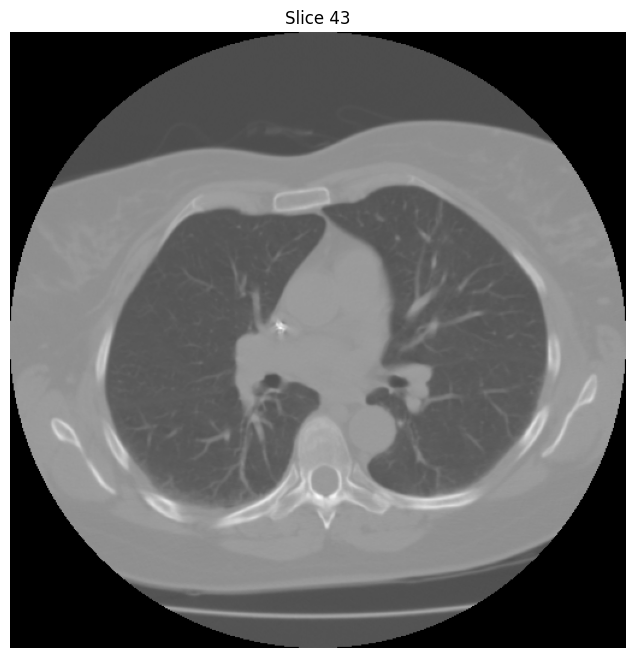

In [4]:
#Show the middle slice
slice_idx = vol.shape[2] // 2

plt.figure(figsize=(8,8))
plt.imshow(vol[:,:,slice_idx], cmap='gray')
plt.title(f"Slice {slice_idx}")
plt.axis("off")

In [5]:
#Obtain modules
nodules = scan.cluster_annotations()

print("Número de nódulos:", len(nodules))

Número de nódulos: 4


In [6]:
#Choose a module
nod = nodules[0]
print("Número de anotaciones del nódulo:", len(nod))

Número de anotaciones del nódulo: 4


In [ ]:
#Create a consnsus mask (take the different annotations and create a single mask)
mask, bbox, masks = consensus(nod, clevel=0.5)

print("Shape máscara:", mask.shape)
print("BBox:", bbox)


Shape máscara: (34, 44, 6)
BBox: (slice(np.int64(294), np.int64(328), None), slice(np.int64(306), np.int64(350), None), slice(np.int64(23), np.int64(29), None))
mask [[[False False False False False False]
  [False False False False False False]
  [False False False False False False]
  ...
  [False False False False False False]
  [False False False False False False]
  [False False False False False False]]

 [[False False False False False False]
  [False False False False False False]
  [False False False False False False]
  ...
  [False False False False False False]
  [False False False False False False]
  [False False False False False False]]

 [[False False False False False False]
  [False False False False False False]
  [False False False False False False]
  ...
  [False False False False False False]
  [False False False False False False]
  [False False False False False False]]

 ...

 [[False False False False False False]
  [False False False False False False]
  [F

In [8]:
#Extract the CT patch corresponding TAC
zmin, zmax = bbox[2].start, bbox[2].stop
ymin, ymax = bbox[1].start, bbox[1].stop
xmin, xmax = bbox[0].start, bbox[0].stop

ct_patch = vol[xmin:xmax, ymin:ymax, zmin:zmax]

print("CT patch:", ct_patch.shape)
print("Mask:", mask.shape)

CT patch: (34, 44, 6)
Mask: (34, 44, 6)


In [9]:
ct_patch.shape == mask.shape

True

Slice índice: 3


(np.float64(-0.5), np.float64(43.5), np.float64(33.5), np.float64(-0.5))

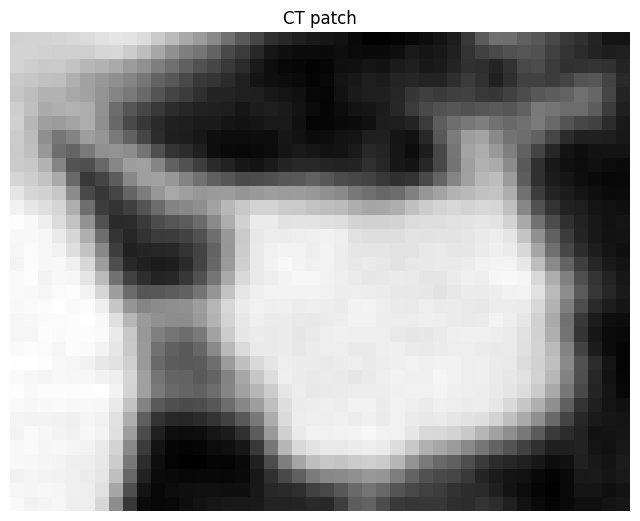

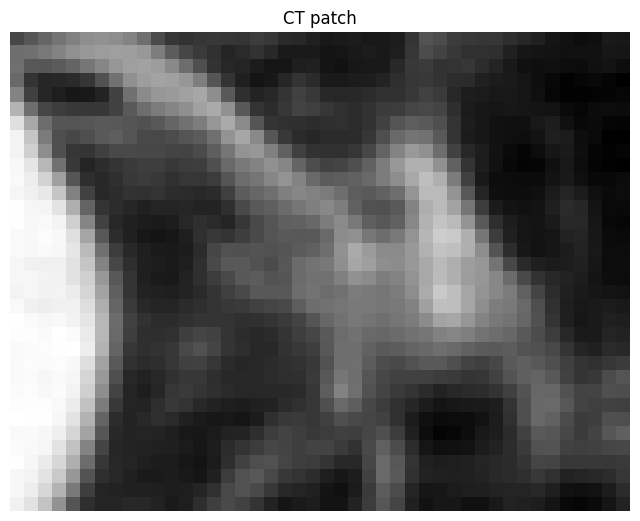

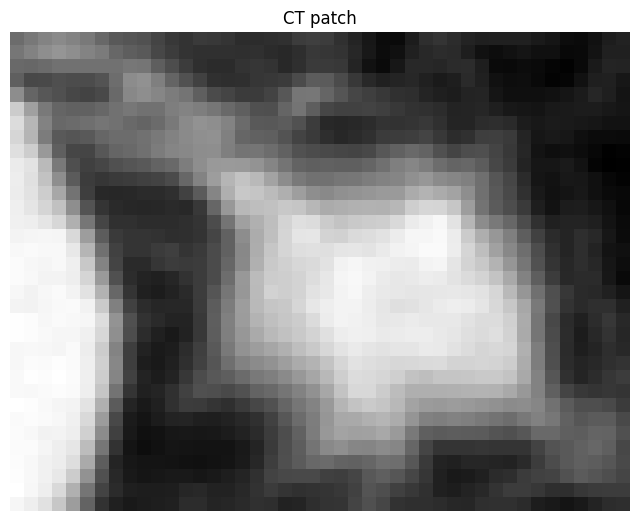

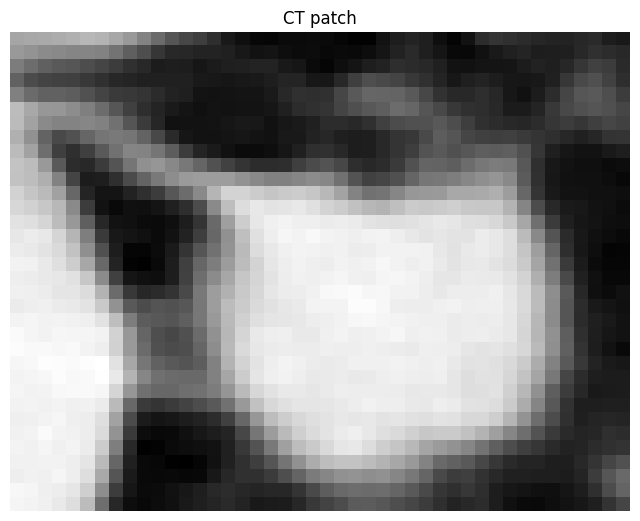

In [ ]:
#Show the CT of the nodule
slice_idx = ct_patch.shape[2] // 2

print("Slice índice:", slice_idx)

plt.figure(figsize=(8,8))
plt.imshow(ct_patch[:,:,slice_idx], cmap='gray')
plt.title("CT patch")
plt.axis("off")

(np.float64(-0.5), np.float64(43.5), np.float64(33.5), np.float64(-0.5))

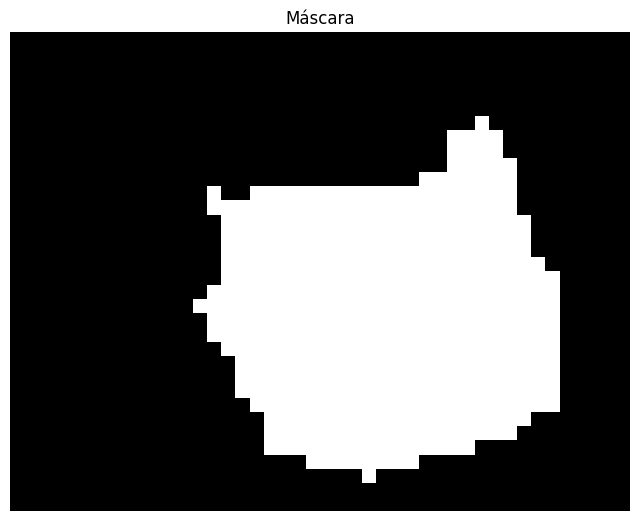

In [11]:
#Show the mask alone
plt.figure(figsize=(8,8))
plt.imshow(mask[:,:,slice_idx], cmap='gray')
plt.title("Máscara")
plt.axis("off")

(np.float64(-0.5), np.float64(43.5), np.float64(33.5), np.float64(-0.5))

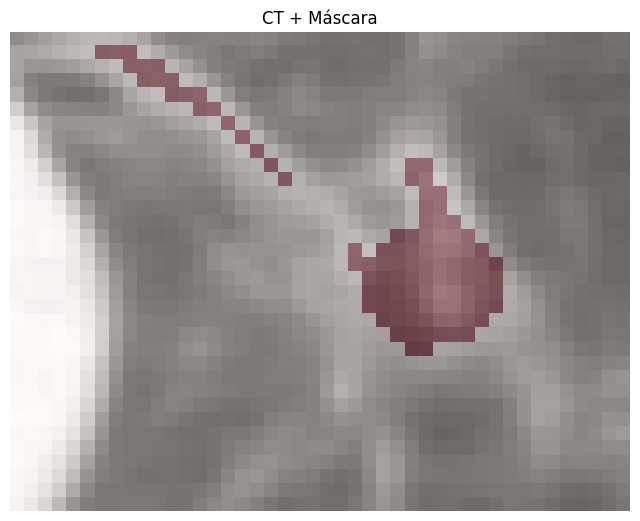

In [ ]:
#Show the CT and the mask together
plt.figure(figsize=(8,8))

plt.imshow(ct_patch[:,:,slice_idx], cmap='gray')

plt.imshow(
    mask[:,:,slice_idx],
    alpha=0.4,
    cmap='Reds'
)

plt.title("CT + Máscara")
plt.axis("off")